In [29]:
import pandas as pd
import numpy as np
pharma_data_filepath = "salesdaily.csv" ; pharm_data_daily = pd.read_csv(pharma_data_filepath)
display(pharm_data_daily.head())

,datum,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06,Year,Month,Hour,Weekday Name
0,1/2/2014,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0,2014,1,248,Thursday
1,1/3/2014,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0,2014,1,276,Friday
2,1/4/2014,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0,2014,1,276,Saturday
3,1/5/2014,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0,2014,1,276,Sunday
4,1/6/2014,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0,2014,1,276,Monday


In [30]:
print("What are the total sales quantities for each drug CATEGORY (ATC code)?")
print("*" * 65)
drug_categories = {
    "M01": ["M01AB", "M01AE"],
    "N02": ["N02BA", "N02BE"],
    "N05": ["N05B", "N05C"],
    "R03": ["R03"],
    "R06": ["R06"]
}

for drug_category, columns in drug_categories.items():
    total = pharm_data_daily[columns].sum().sum()
    print(f"{drug_category} class drugs: {total:.0f}")

What are the total sales quantities for each drug CATEGORY (ATC code)?
*****************************************************************
M01 class drugs: 18806
N02 class drugs: 71178
N05 class drugs: 19896
R03 class drugs: 11609
R06 class drugs: 6108


In [31]:
print("Which INDIVIDUAL drug brands have the highest total sales?")
print("*" * 65)
drug_classes = {
    "M01": ["M01AB", "M01AE"],
    "N02": ["N02BA", "N02BE"],
    "N05": ["N05B", "N05C"],
}

for drug_class, columns in drug_classes.items():
    winner = pharm_data_daily[columns].sum().idxmax()
    print(f"Between the class {drug_class} drugs: {winner} has higher sales.")

Which INDIVIDUAL drug brands have the highest total sales?
*****************************************************************
Between the class M01 drugs: M01AB has higher sales.
Between the class N02 drugs: N02BE has higher sales.
Between the class N05 drugs: N05B has higher sales.


In [32]:
print("Which three drugs have the highest sales in January 2015, July 2016, September 2017?")
print("*" * 65)
cols = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
print("January 2015:")
print(pharm_data_daily.loc[(pharm_data_daily["Month"] == 1) & (pharm_data_daily["Year"] == 2015), cols].sum().nlargest(3))
print("*" * int(64/2))
print("July 2016:")
print(pharm_data_daily.loc[(pharm_data_daily["Month"] == 7) & (pharm_data_daily["Year"] == 2016), cols].sum().nlargest(3))
print("*" * int(64/2))
print("September 2017:")
print(pharm_data_daily.loc[(pharm_data_daily["Month"] == 9) & (pharm_data_daily["Year"] == 2017), cols].sum().nlargest(3))

Which three drugs have the highest sales in January 2015, July 2016, September 2017?
*****************************************************************
January 2015:
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64
********************************
July 2016:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64
********************************
September 2017:
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


In [33]:
print("Which drug has sold the most often in 2017?")
print("*" * 65)
print(pharm_data_daily.loc[pharm_data_daily["Year"] == 2017, cols].sum().idxmax())

Which drug has sold the most often in 2017?
*****************************************************************
N02BE


Which drug category has the highest average daily sales?
*****************************************************************
N02
34


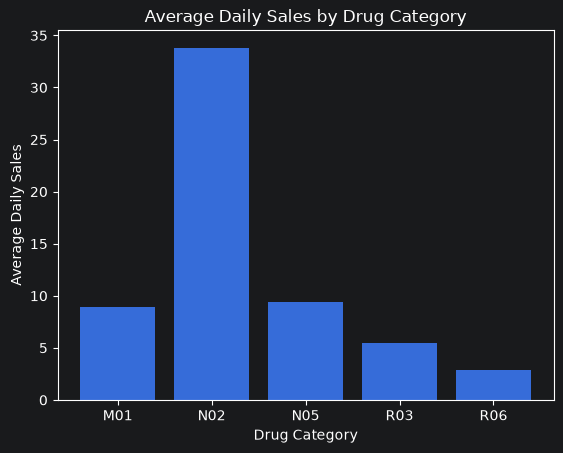

In [34]:
print("Which drug category has the highest average daily sales?")
print("*" * 65)
total_days = pharm_data_daily["datum"].count()
drug_categories = {
    "M01": pharm_data_daily[["M01AB", "M01AE"]].sum().sum(),
    "N02": pharm_data_daily[["N02BA", "N02BE"]].sum().sum(),
    "N05": pharm_data_daily[["N05B", "N05C"]].sum().sum(),
    "R03": pharm_data_daily["R03"].sum(),
    "R06": pharm_data_daily["R06"].sum()
}

averages = {}
for category, total in drug_categories.items():
    averages[category] = total / total_days

print(max(averages, key=averages.get))
print(round((pharm_data_daily[["N02BA", "N02BE"]].sum().sum()) / total_days))

import matplotlib.pyplot as plt
plt.bar(averages.keys(), averages.values())
plt.title("Average Daily Sales by Drug Category")
plt.xlabel("Drug Category")
plt.ylabel("Average Daily Sales")

plt.show()

Are respiratory drugs (R03) sold more during specific months?
*****************************************************************


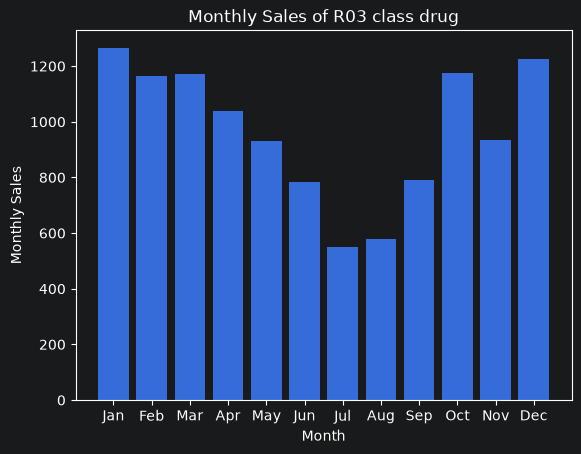

Month
Jan    1265.0
Feb    1166.0
Mar    1170.0
Apr    1039.0
May     931.0
Jun     783.0
Jul     550.0
Aug     577.0
Sep     792.0
Oct    1175.0
Nov     934.0
Dec    1227.0
Name: R03, dtype: float64


In [35]:
print("Are respiratory drugs (R03) sold more during specific months?")
print("*" * 65)
R03_by_month = pharm_data_daily.groupby("Month")["R03"].sum().round()
month_names = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

R03_by_month.index = R03_by_month.index.map(month_names)

plt.bar(R03_by_month.index, R03_by_month.values)
plt.title("Monthly Sales of R03 class drug")
plt.xlabel("Month")
plt.ylabel("Monthly Sales")

plt.show()
print(R03_by_month)

In [36]:
print("On which day of the week is the second drug (M01AE) most often sold?")
print("*" * 65)
sales_by_weekday = pharm_data_daily.groupby("Weekday Name")["M01AE"].sum()
print(round(sales_by_weekday).idxmax())

On which day of the week is the second drug (M01AE) most often sold?
*****************************************************************
Sunday


In [37]:
print("Which drug has sold most often on Mondays in 2017?")
print("*" * 65)
monday_2017 = pharm_data_daily.loc[
    (pharm_data_daily["Year"] == 2017) &
    (pharm_data_daily["Weekday Name"] == "Monday"),
    cols
]

totals = monday_2017.sum()

highest_name = totals.idxmax()
highest_sales = totals.max()

print(f"The drug most often sold on Mondays in 2017 was {highest_name}")
print(f"with the total number of sales being: {highest_sales:.0f}")

#https://roadmap.sh/projects/pharmaceutical-sales-data?fl=1

Which drug has sold most often on Mondays in 2017?
*****************************************************************
The drug most often sold on Mondays in 2017 was N02BE
with the total number of sales being: 1161
